## **Clone repo**

In [2]:
%cd /kaggle/working

!git clone https://github.com/HCMUS-VIR-Nhom8/DINOv3-FAISS-HNSW-SOP-VisualProductSearch.git

/kaggle/working
Cloning into 'DINOv3-FAISS-HNSW-SOP-VisualProductSearch'...
remote: Enumerating objects: 428, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 428 (delta 45), reused 152 (delta 44), pack-reused 268 (from 3)
Receiving objects: 100% (428/428), 266.92 MiB | 29.30 MiB/s, done.
Resolving deltas: 100% (99/99), done.
Updating files: 100% (243/243), done.


In [3]:
%cd /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch

/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch


## **Thêm dataset SOP**

In [4]:
from pathlib import Path

for path in Path("/kaggle/input").rglob("Ebay_train.txt"):
    print(path)

## **Cài thư viện**

In [5]:
%cd /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch
!pip install -q -r requirements.txt

/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 74.3 MB/s eta 0:00:00:00:0100:01


In [6]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## ** Chạy notebook theo thứ tự**

1. 01-sampling.ipynb
2. 02-baseline-offline.ipynb
3. 02-baseline-online.ipynb
4. 03-proposed-offline.ipynb
5. 03-proposed-online.ipynb

In [7]:
# from pathlib import Path

# matches = list(Path("/kaggle/input").rglob("Ebay_train.txt"))

# print(matches)

## **Kiểm tra notebook 01-sampling.ipynb có gì**

In [8]:
# from pathlib import Path

# repo = Path("/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch")
# nb = repo / "notebooks" / "01-sampling.ipynb"

# print(nb.exists(), nb)

In [9]:
# from pathlib import Path

# repo = Path("/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch")

# p = repo / "data" / "sampled" / "sop_20k.csv"

# print("exists =", p.exists())
# print("size   =", p.stat().st_size if p.exists() else None)

In [10]:
# %cd /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch

# !jupyter nbconvert \
#   --to notebook \
#   --execute notebooks/01-sampling.ipynb \
#   --output /kaggle/working/01-sampling-executed.ipynb \
#   --ExecutePreprocessor.timeout=-1

## ** chạy 02-baseline-offline.ipynb **

In [11]:
# %cd /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch

# !jupyter nbconvert \
#   --to notebook \
#   --execute notebooks/02-baseline-offline.ipynb \
#   --output /kaggle/working/02-baseline-offline-executed.ipynb \
#   --ExecutePreprocessor.timeout=-1

## **Hugging Face login OK?**

In [12]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

login(token=hf_token)

print("Hugging Face login OK")

Hugging Face login OK


## **Chạy 03-proposed-offline.ipynb**

In [13]:
# %cd /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch

# !jupyter nbconvert \
#   --to notebook \
#   --execute notebooks/03-proposed-offline.ipynb \
#   --output /kaggle/working/03-proposed-offline-executed.ipynb \
#   --ExecutePreprocessor.timeout=-1

## **03-proposed-online.ipynb**

In [14]:
# %cd /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch

# !jupyter nbconvert \
#   --to notebook \
#   --execute notebooks/03-proposed-online.ipynb \
#   --output /kaggle/working/03-proposed-online-executed.ipynb \
#   --ExecutePreprocessor.timeout=-1

## **Chuẩn bị Top-N candidate**

In [15]:
from pathlib import Path
import sys

REPO = Path("/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch")
sys.path.insert(0, str(REPO))

%cd /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch

/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch


## **setup đường dẫn**

In [16]:
# ==============================================================================
# KAGGLE SETUP BLOCK (INDEPENDENT BLOCK)
# ==============================================================================
import os
import sys
import subprocess
from pathlib import Path

# Detect Kaggle environment
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

if IS_KAGGLE:
    print("--- Detected Kaggle Environment ---")
    
    # 1. Clone repository if not present
    REPO_URL = "https://github.com/HCMUS-VIR-Nhom8/DINOv3-FAISS-HNSW-SOP-VisualProductSearch.git"
    REPO_DIR = Path("/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch")
    
    if not REPO_DIR.exists():
        print(f"Cloning repository: {REPO_URL}")
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

    # swich to branch "experiments"
    print("Switching to branch: experiments")
    try:
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", "experiments"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"Error switching branch: {e}. Attempting to fetch first...")
        subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin"], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", "experiments"], check=True)
    
    # Change working directory of the kernel to notebooks directory
    # so that PROJECT_ROOT = Path("..").resolve() works correctly
    NOTEBOOKS_DIR = REPO_DIR / "notebooks"
    if NOTEBOOKS_DIR.exists():
        os.chdir(str(NOTEBOOKS_DIR))
        print(f"Changed working directory to: {os.getcwd()}")
        
    # Add project root to sys.path so src imports work
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))
        print("Added repository root to python path.")
        
    # 2. Download and unzip dataset from Google Drive
    DATA_DIR = REPO_DIR / "data" / "raw" / "Stanford_Online_Products"
    ZIP_PATH = REPO_DIR / "Stanford_Online_Products.zip"
    
    if not DATA_DIR.exists() or not (DATA_DIR / "Ebay_train.txt").exists():
        print("Dataset not found. Downloading from Google Drive...")
        
        # Install gdown if needed
        try:
            import gdown
        except ImportError:
            print("Installing gdown...")
            subprocess.run([sys.executable, "-m", "pip", "install", "gdown"], check=True)
            import gdown
            
        # Download Stanford Online Products ZIP
        file_id = "1TclrpQOF_ullUP99wk_gjGN8pKvtErG8"
        url = f"https://drive.google.com/uc?id={file_id}"
        print(f"Downloading from Google Drive ID: {file_id}")
        gdown.download(url, str(ZIP_PATH), quiet=False)
        
        # Extract the zip file
        print("Extracting dataset...")
        import zipfile
        raw_dir = REPO_DIR / "data" / "raw"
        raw_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(str(ZIP_PATH), 'r') as zip_ref:
            zip_ref.extractall(str(raw_dir))
            
        print("Dataset extraction completed.")
        
        # Clean up zip file
        if ZIP_PATH.exists():
            ZIP_PATH.unlink()
            print("Cleaned up ZIP file.")
            
    # Note on HF login for gated DINOv3
    print("\n--- Hugging Face Access Note ---")
    print("DINOv3 is a gated Hugging Face model. If access token is required, run:")
    print("from huggingface_hub import login; login(token='YOUR_HF_TOKEN')\n")
else:
    print("Running in local environment. Setup skipped.")

--- Detected Kaggle Environment ---
Switching to branch: experiments


Switched to a new branch 'experiments'


Branch 'experiments' set up to track remote branch 'experiments' from 'origin'.
Changed working directory to: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/notebooks
Dataset not found. Downloading from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1TclrpQOF_ullUP99wk_gjGN8pKvtErG8
From (redirected): https://drive.google.com/uc?id=1TclrpQOF_ullUP99wk_gjGN8pKvtErG8&confirm=t&uuid=3164b5d7-c19e-4923-920d-f38246827354
To: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/Stanford_Online_Products.zip
100%|██████████| 3.08G/3.08G [00:20<00:00, 148MB/s] 


Extracting dataset...
Dataset extraction completed.
Cleaned up ZIP file.

--- Hugging Face Access Note ---
DINOv3 is a gated Hugging Face model. If access token is required, run:
from huggingface_hub import login; login(token='YOUR_HF_TOKEN')



## **copy cell từ 03-proposed-online.ipynb**

In [17]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

# ---------------------------------------------------------------------------
# Dataset — PHẢI dùng đúng split đã tạo ở Notebook 02 (baseline). Không
# sampling lại, không tự tạo query/gallery split khác, để so sánh baseline
# vs proposed là fair (cùng gallery, cùng query, cùng ground-truth).
# ---------------------------------------------------------------------------
SPLIT_DIR = PROJECT_ROOT / "data" / "sampled"
SAMPLE_FILE = SPLIT_DIR / "sop_20k.csv"
GALLERY_FILE = SPLIT_DIR / "baseline_gallery.csv"
QUERY_FILE = SPLIT_DIR / "baseline_query.csv"

# Output proposed
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "proposed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
QUAL_DIR = OUTPUT_DIR / "qualitative"

EMBEDDING_FILE = OUTPUT_DIR / "gallery_embeddings.npy"
GALLERY_META_FILE = OUTPUT_DIR / "gallery_metadata.csv"
HNSW_INDEX_FILE = OUTPUT_DIR / "gallery_hnsw.index"
QUERY_RESULTS_FILE = OUTPUT_DIR / "retrieval_results.npy"
QUERY_SCORES_FILE = OUTPUT_DIR / "retrieval_scores.npy"
METRICS_FILE = OUTPUT_DIR / "metrics.json"
LATENCY_FILE = OUTPUT_DIR / "latency.json"
CONFIG_FILE = OUTPUT_DIR / "config.json"

# ---------------------------------------------------------------------------
# Model — DINOv3. Tên model lấy từ configs/proposed.yaml của repo, KHÔNG
# hard-code khác đi. DINOV3_LOCAL_PATH cho phép trỏ tới checkpoint cục bộ
# (thư mục chứa config.json/model weights kiểu HuggingFace) thay vì Hub.
# ---------------------------------------------------------------------------
DINOV3_MODEL_NAME = "facebook/dinov3-vitb16-pretrain-lvd1689m"  # configs/proposed.yaml -> model.name
DINOV3_LOCAL_PATH = None  # vd: "/path/to/local/dinov3-checkpoint"
MODEL_SOURCE = DINOV3_LOCAL_PATH if DINOV3_LOCAL_PATH else DINOV3_MODEL_NAME

# ---------------------------------------------------------------------------
# Preprocessing — theo đúng ProposedPreprocessor (src/preprocessing/pipeline.py)
# và giá trị mặc định trong configs/proposed.yaml. Localization/segmentation
# (Grounding DINO / SAM) KHÔNG được bật: tài liệu phương pháp (mục 4.1.2.3)
# mô tả đây là các thành phần "có thể thay thế" trong prototype, và repo
# hiện chưa gắn checkpoint thật cho hai bước này (CONFIGURABLE, không phải
# method chính thức bắt buộc).
# ---------------------------------------------------------------------------
RESIZE_LONG_SIDE = 1024
TARGET_SIZE = 518            # kích thước sau letterbox
IMAGE_SIZE = TARGET_SIZE     # alias cho đúng tên biến yêu cầu trong đề bài
PADDING_RATIO = 0.10          # chưa dùng vì localization/segmentation đang tắt
BLUR_THRESHOLD = 50.0
JPEG_THRESHOLD = 8.0
USE_ILLUMINATION_CORRECTION = True
CLAHE_CLIP_LIMIT = 2.0

BATCH_SIZE = 16
NUM_WORKERS = 2

# ---------------------------------------------------------------------------
# FAISS HNSW — mặc định lấy từ configs/proposed.yaml (mục 4.1.7 trong tài
# liệu phương pháp). Đổi ở đây để thử nghiệm đánh đổi recall/latency/memory.
# ---------------------------------------------------------------------------
HNSW_M = 32
HNSW_EF_CONSTRUCTION = 200
HNSW_EF_SEARCH = 64

# ---------------------------------------------------------------------------
# Metadata re-ranking — dùng ĐÚNG công thức đã hiện thực trong
# src/reranking/metadata.py::category_consistency_rerank (không tự bịa công
# thức khác — xem mục 14 của yêu cầu).
#
# LƯU Ý QUAN TRỌNG (xem README của repo): SOP không có metadata dạng
# title/brand/mô tả văn bản cho ảnh truy vấn. Do đó công thức này KHÔNG so
# khớp metadata của query với candidate (không phải oracle match), mà tính
# điểm đồng thuận (consensus) super_class_id ngay trong tập Top-N candidate:
#
#     meta_score(candidate) = tần suất super_class_id của candidate đó
#                              trong Top-N candidates / N
#     final_score = alpha_visual * visual_score_normalized
#                   + (1 - alpha_visual) * meta_score
#
# Đây là một CONFIGURABLE EXPERIMENTAL CHOICE đã được README của repo xác
# nhận, KHÔNG PHẢI một công thức chính thức đã được đề tài chứng minh tối
# ưu. Nếu có metadata text/brand thật, hãy thay hàm rerank tương ứng thay vì
# coi category-consistency là mặc định vĩnh viễn.
# ---------------------------------------------------------------------------
ENABLE_RERANKING = True
RERANK_CANDIDATES = 100      # = retrieval.candidate_k trong configs/proposed.yaml
ALPHA_VISUAL = 0.85          # = reranking.alpha_visual trong configs/proposed.yaml
VISUAL_WEIGHT = ALPHA_VISUAL
METADATA_WEIGHT = 1.0 - ALPHA_VISUAL

# ---------------------------------------------------------------------------
# Evaluation — PHẢI trùng KS đã dùng ở Notebook 02 để so sánh công bằng.
# ---------------------------------------------------------------------------
KS = [1, 5, 10, 20, 50, 100]
MAX_QUERIES = None           # None = toàn bộ query set
RANDOM_SEED = 42

# Device — đổi thành "cpu" nếu không có GPU.
DEVICE = "cuda"

N_QUALITATIVE = 20            # số lượng ảnh minh họa xuất ra qualitative/

print("PROJECT_ROOT :", PROJECT_ROOT)
print("GALLERY_FILE :", GALLERY_FILE)
print("QUERY_FILE   :", QUERY_FILE)
print("OUTPUT_DIR   :", OUTPUT_DIR)
print("MODEL_SOURCE :", MODEL_SOURCE)

PROJECT_ROOT : /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch
GALLERY_FILE : /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/data/sampled/baseline_gallery.csv
QUERY_FILE   : /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/data/sampled/baseline_query.csv
OUTPUT_DIR   : /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/outputs/proposed
MODEL_SOURCE : facebook/dinov3-vitb16-pretrain-lvd1689m


In [18]:
%pip install faiss-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.2/135.2 MB 4.9 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [19]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import transformers

try:
    import faiss
except ImportError as e:
    raise ImportError(
        "Không import được faiss. Cài đặt bằng:\n"
        "  pip install faiss-cpu   # hoặc faiss-gpu nếu có CUDA phù hợp\n"
        f"Lỗi gốc: {e}"
    )

# Cho phép "from src...." hoạt động khi notebook chạy từ thư mục notebooks/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("Transformers:", transformers.__version__)
print("FAISS       :", getattr(faiss, "__version__", "n/a"))
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
elif DEVICE == "cuda":
    print(
        "\u26a0 DEVICE='cuda' nhưng không có GPU khả dụng. "
        "Hãy đổi DEVICE='cpu' ở Cell Configuration trước khi chạy tiếp."
    )

Python      : 3.12.13
PyTorch     : 2.10.0+cu128
Transformers: 5.0.0
FAISS       : 1.15.0
CUDA available: True
GPU: Tesla T4


In [20]:
# Theo mục 23 của yêu cầu: dùng lại module đã có trong src/ thay vì viết lại.
try:
    from src.preprocessing.pipeline import ProposedPreprocessor
    from src.models.encoder import DINOv3Encoder
    from src.retrieval.hnsw import HNSWRetriever
    from src.reranking.metadata import category_consistency_rerank
except ImportError as e:
    raise ImportError(
        "Không import được các module trong src/. Kiểm tra:\n"
        "  1. Notebook đang chạy từ thư mục notebooks/ (PROJECT_ROOT = ..)\n"
        "  2. Repo có đầy đủ src/preprocessing/pipeline.py, src/models/encoder.py, "
        "src/retrieval/hnsw.py, src/reranking/metadata.py\n"
        f"Lỗi gốc: {e}"
    )

print("\u2713 Đã import ProposedPreprocessor, DINOv3Encoder, HNSWRetriever, "
      "category_consistency_rerank từ src/.")

✓ Đã import ProposedPreprocessor, DINOv3Encoder, HNSWRetriever, category_consistency_rerank từ src/.


In [21]:
gallery_df = pd.read_csv(GALLERY_FILE).reset_index(drop=True)
query_df = pd.read_csv(QUERY_FILE).reset_index(drop=True)

print("Gallery:", len(gallery_df), "| classes:", gallery_df["class_id"].nunique())
print("Query  :", len(query_df), "| classes:", query_df["class_id"].nunique())

display(gallery_df.head())

Gallery: 10000 | classes: 10000
Query  : 10000 | classes: 10000


,image_id,class_id,super_class_id,path,image_path,source_split,exists
0,1,1,1,bicycle_final/111085122871_0.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train,True
1,36,6,1,bicycle_final/111476691561_4.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train,True
2,65,11,1,bicycle_final/111588452395_2.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train,True
3,70,13,1,bicycle_final/111611735309_1.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train,True
4,76,14,1,bicycle_final/111612717975_4.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train,True


In [22]:
required_columns = {"image_id", "class_id", "image_path"}

for name, df in [("gallery_df", gallery_df), ("query_df", query_df)]:
    missing_cols = required_columns - set(df.columns)
    if missing_cols:
        raise ValueError(f"{name} thiếu cột bắt buộc: {missing_cols}")

# Mỗi query class phải có ít nhất 1 ảnh trong gallery (positive tồn tại)
missing_query_classes = set(query_df["class_id"]) - set(gallery_df["class_id"])
assert len(missing_query_classes) == 0, (
    f"{len(missing_query_classes)} class trong query không có ảnh gallery tương ứng."
)

# Query và gallery không được trùng image_id (tránh self-retrieval ảo)
overlap = set(query_df["image_id"]) & set(gallery_df["image_id"])
assert len(overlap) == 0, f"Query và gallery bị overlap {len(overlap)} image_id."

# Kiểm tra image path tồn tại trên đĩa
for name, df in [("gallery_df", gallery_df), ("query_df", query_df)]:
    exists = df["image_path"].map(os.path.exists)
    if not exists.all():
        n_missing = int((~exists).sum())
        raise FileNotFoundError(f"{name} có {n_missing} image_path không tồn tại trên đĩa.")

# Reranking cần super_class_id — nếu thiếu, báo lỗi rõ ràng thay vì âm thầm tắt.
if ENABLE_RERANKING and "super_class_id" not in gallery_df.columns:
    raise ValueError(
        "ENABLE_RERANKING=True nhưng gallery_df không có cột 'super_class_id'.\n"
        "category_consistency_rerank() cần cột này để tính metadata score.\n"
        "Hãy đảm bảo Notebook 01 giữ lại cột super_class_id khi tạo sop_20k.csv, "
        "hoặc đặt ENABLE_RERANKING = False ở Cell Configuration để chạy HNSW-only."
    )

print(
    "\u2713 Split hợp lệ: không overlap, mọi query class đều có gallery, "
    "mọi image_path tồn tại"
    + (", có super_class_id cho reranking." if ENABLE_RERANKING else ".")
)

✓ Split hợp lệ: không overlap, mọi query class đều có gallery, mọi image_path tồn tại, có super_class_id cho reranking.


In [23]:
!pip install python-dotenv

In [24]:
# !hf auth login --token SECRET_HF_TOKEN--add-to-git-credential
import os, sys
from dotenv import load_dotenv
from huggingface_hub import login

# khi chay duoi local
load_dotenv()
HF_TOKEN = os.getenv("SECRET_HF_TOKEN")
try:
    login(token=HF_TOKEN)
    print("✅ Hugging Face login successful")
except Exception as exc:
    print("⚠️ Hugging Face login failed – proceeding with token‑only loading", exc,
          file=sys.stderr)

✅ Hugging Face login successful


In [25]:
try:
    dinov3 = DINOv3Encoder(MODEL_SOURCE, DEVICE)
except Exception as e:
    raise RuntimeError(
        f"Không load được DINOv3 ({MODEL_SOURCE}).\n"
        "Nguyên nhân thường gặp:\n"
        "  1. Chưa đăng nhập Hugging Face hoặc chưa được cấp quyền truy cập "
        "model gated -> chạy `huggingface-cli login` và xin quyền tại trang "
        "model card trên huggingface.co.\n"
        "  2. Không có kết nối mạng tới huggingface.co.\n"
        "  3. DINOV3_LOCAL_PATH (Cell Configuration) trỏ sai đường dẫn checkpoint cục bộ.\n"
        f"Lỗi gốc: {e}"
    )

print("\u2713 Đã load DINOv3Encoder")
print("Device       :", dinov3.device)
print("Embedding dim:", dinov3.dim)

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✓ Đã load DINOv3Encoder
Device       : cuda
Embedding dim: 768


In [26]:
# LƯU Ý: DINOv3Encoder.__init__ (src/models/encoder.py) hiện chỉ gọi
# .to(device).eval() và CHƯA tự set requires_grad_(False) cho tham số.
# Để đúng yêu cầu "frozen backbone" của tài liệu phương pháp (mục 4.1.3.3:
# "Có thể sử dụng như một backbone đóng băng"), notebook tự đóng băng tường
# minh ở đây.
# TODO (repo): cân nhắc chuyển đoạn freeze này vào DINOv3Encoder.__init__.
for p in dinov3.model.parameters():
    p.requires_grad_(False)

num_params = sum(p.numel() for p in dinov3.model.parameters())
num_trainable = sum(p.numel() for p in dinov3.model.parameters() if p.requires_grad)

print("Tổng số tham số     :", f"{num_params:,}")
print("Tham số có thể train:", f"{num_trainable:,}")
print("model.training =", dinov3.model.training)

assert num_trainable == 0, "DINOv3 backbone chưa được đóng băng hoàn toàn."
assert dinov3.model.training is False, "DINOv3 model chưa ở chế độ eval()."

print("\u2713 Backbone đã đóng băng và ở chế độ eval — đúng yêu cầu frozen backbone.")

Tổng số tham số     : 85,660,416
Tham số có thể train: 0
model.training = False
✓ Backbone đã đóng băng và ở chế độ eval — đúng yêu cầu frozen backbone.


In [27]:
# Load offline proposed embeddings and HNSW index
from src.retrieval.hnsw import HNSWRetriever

if not EMBEDDING_FILE.exists() or not GALLERY_META_FILE.exists() or not HNSW_INDEX_FILE.exists():
    raise FileNotFoundError(
        f"Offline proposed embeddings/index not found under {OUTPUT_DIR}. "
        f"Please run the offline notebook (03_proposed_offline.ipynb) first."
    )

gallery_embeddings = np.load(EMBEDDING_FILE)
gallery_df = pd.read_csv(GALLERY_META_FILE).reset_index(drop=True)
hnsw_retriever = HNSWRetriever.load(HNSW_INDEX_FILE)

# Placeholders for variables referenced in evaluation
hnsw_build_time = 0.0
gallery_encode_time = 0.0

print("Loaded offline proposed artifacts:")
print("Gallery Embeddings Shape:", gallery_embeddings.shape)
print("HNSW Index ntotal       :", hnsw_retriever.index.ntotal)

Loaded offline proposed artifacts:
Gallery Embeddings Shape: (10000, 768)
HNSW Index ntotal       : 10000


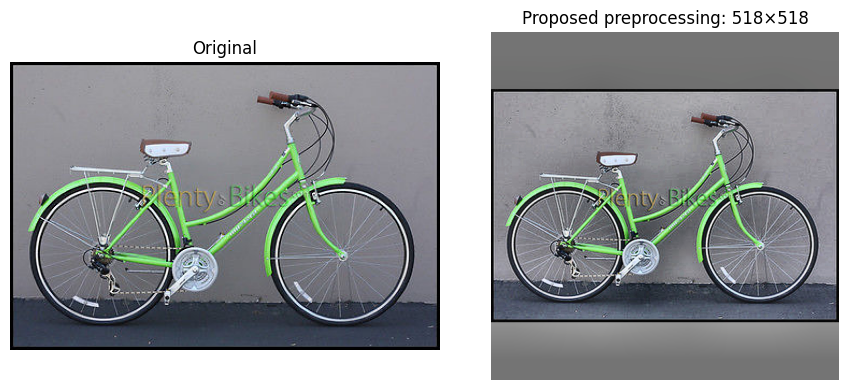

blur_score: 196.75783953625017 | flags: {'blur_flag': False, 'jpeg_flag': False}
Lưu ý: AutoImageProcessor của HuggingFace sẽ áp dụng thêm resize/normalize riêng của DINOv3 lên ảnh đã letterbox này khi gọi dinov3.encode() — đây là thiết kế sẵn có của repo (DINOv3Encoder), không phải augmentation bổ sung do notebook này thêm vào.


In [28]:
proposed_preprocessor = ProposedPreprocessor(
    resize_long_side=RESIZE_LONG_SIDE,
    target_size=TARGET_SIZE,
    padding_ratio=PADDING_RATIO,
    blur_threshold=BLUR_THRESHOLD,
    jpeg_threshold=JPEG_THRESHOLD,
    use_illumination=USE_ILLUMINATION_CORRECTION,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
)

preview_row = gallery_df.iloc[0]
preview_original = Image.open(preview_row["image_path"]).convert("RGB")
preview_output = proposed_preprocessor(preview_row["image_path"])

plt.figure(figsize=(9, 4))
ax = plt.subplot(1, 2, 1)
ax.imshow(preview_original)
ax.set_title("Original")
ax.axis("off")

ax = plt.subplot(1, 2, 2)
ax.imshow(preview_output.image)
ax.set_title(f"Proposed preprocessing: {TARGET_SIZE}\u00d7{TARGET_SIZE}")
ax.axis("off")
plt.tight_layout()
plt.show()

print("blur_score:", preview_output.blur_score, "| flags:", preview_output.metadata)
print(
    "Lưu ý: AutoImageProcessor của HuggingFace sẽ áp dụng thêm resize/normalize "
    "riêng của DINOv3 lên ảnh đã letterbox này khi gọi dinov3.encode() — đây là "
    "thiết kế sẵn có của repo (DINOv3Encoder), không phải augmentation bổ sung "
    "do notebook này thêm vào."
)

In [29]:
def encode_query(image_path, preprocessor, encoder, device):
    """
    Online query encoding: load ảnh -> preprocessing đề xuất -> DINOv3 -> L2.

    Trả về (embedding [1, D], elapsed_seconds). Đo latency RIÊNG cho bước
    này — không gộp với search/rerank (mục 11 và 17 của yêu cầu).
    """
    out = preprocessor(image_path)

    if device == "cuda" and torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()

    embedding = encoder.encode([out.image])  # đã L2-normalize bên trong

    if device == "cuda" and torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    return embedding, elapsed

In [30]:
query_row = query_df.iloc[0]
q_embedding, q_encode_time = encode_query(
    query_row["image_path"], proposed_preprocessor, dinov3, DEVICE
)

print("Query image_id:", query_row["image_id"], "| GT class:", query_row["class_id"])
print("Embedding shape:", q_embedding.shape)
print(f"Encoding latency: {q_encode_time * 1000:.2f} ms")
assert np.allclose(np.linalg.norm(q_embedding, axis=1), 1.0, atol=1e-4)

Query image_id: 7 | GT class: 1
Embedding shape: (1, 768)
Encoding latency: 1555.99 ms


In [31]:
def hnsw_search(query_embedding, index, candidate_k):
    """
    ANN search trên FAISS HNSW. Trả về (ids, scores, elapsed_seconds).
    Đo latency RIÊNG cho search, tách khỏi encoding và reranking.
    """
    start = time.perf_counter()
    scores, ids = index.search(query_embedding, candidate_k)
    elapsed = time.perf_counter() - start
    return ids, scores, elapsed


q_ids, q_scores, q_search_time = hnsw_search(q_embedding, hnsw_retriever, RERANK_CANDIDATES)
print(f"Search latency: {q_search_time * 1000:.2f} ms")
print("Top-5 candidate ids    :", q_ids[0, :5])
print("Top-5 candidate scores :", q_scores[0, :5])

Search latency: 1.13 ms
Top-5 candidate ids    : [  17 5109 5277   27 5164]
Top-5 candidate scores : [0.8095089  0.6647965  0.62647724 0.62505174 0.6157494 ]


In [32]:
def safe_class_lookup(ids_row, class_id_array):
    """
    Tra class_id theo vị trí, KHÔNG dùng numpy negative-index cho id=-1
    (FAISS trả -1 khi không đủ candidate) — tránh lỗi âm thầm trỏ nhầm
    phần tử cuối của mảng (mục 28 của yêu cầu: không silently ignore lỗi).
    """
    ids_row = np.asarray(ids_row)
    out = np.full(ids_row.shape, -1, dtype="int64")
    valid = ids_row >= 0
    out[valid] = np.asarray(class_id_array)[ids_row[valid]]
    return out


rows = []
retrieved_classes_preview = safe_class_lookup(q_ids[0][:10], gallery_df["class_id"].to_numpy())
for rank, (idx, score, cls) in enumerate(
    zip(q_ids[0][:10], q_scores[0][:10], retrieved_classes_preview), start=1
):
    rows.append({
        "rank": rank,
        "gallery_index": int(idx),
        "class_id": int(cls),
        "similarity": float(score),
        "correct": int(cls) == int(query_row["class_id"]),
    })

display(pd.DataFrame(rows))

,rank,gallery_index,class_id,similarity,correct
0,1,17,36,0.809509,False
1,2,5109,11356,0.664796,False
2,3,5277,11751,0.626477,False
3,4,27,62,0.625052,False
4,5,5164,11480,0.615749,False
5,6,170,400,0.602579,False
6,7,192,446,0.584716,False
7,8,46,96,0.584713,False
8,9,236,540,0.578794,False
9,10,233,536,0.572963,False


## Chuẩn bị Top-N candidate

Đã copy từ `03-proposed-online.ipynb`:

- Setup môi trường và cấu hình.
- Load query/gallery, DINOv3 và HNSW.
- Encode query.
- HNSW retrieval với `RERANK_CANDIDATES = 100`.
- Hiển thị kết quả Top-N trước reranking.

Hiện pipeline dừng tại:

`Query → DINOv3 → HNSW → Top-100 candidates`

Bước tiếp theo: tích hợp RRT để rerank Top-100.

## **Cần có third_party/RerankingTransformer nên phải pull**

In [33]:
%cd /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch

!git branch --show-current
!git pull origin main

/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch
experiments
From https://github.com/HCMUS-VIR-Nhom8/DINOv3-FAISS-HNSW-SOP-VisualProductSearch
 * branch            main       -> FETCH_HEAD
Updating 04ec9c5..36f8858
Fast-forward
 README.md                                          |     50 +-
 third_party/RerankingTransformer/.gitignore        |    129 +
 third_party/RerankingTransformer/LICENSE           |    674 +
 third_party/RerankingTransformer/README.md         |     34 +
 third_party/RerankingTransformer/RRT_GLD/README.md |    288 +
 .../RerankingTransformer/RRT_GLD/data/.gitignore   |      4 +
 .../RRT_GLD/data/gldv2/train.txt                   | 322008 ++++++++++++++++
 .../RRT_GLD/data/oxford5k/gnd_roxford5k.pkl        |    Bin 0 -> 149871 bytes
 .../RRT_GLD/data/oxford5k/test_gallery.txt         |   4993 +
 .../RRT_GLD/data/oxford5k/test_query.txt           |     70 +
 .../RRT_GLD/data/paris6k/gnd_rparis6k.pkl          |    Bin 0 -> 276508 bytes
 .../RRT_GLD/data/pari

In [34]:
from pathlib import Path

RRT_SOP = Path(
    "/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/"
    "third_party/RerankingTransformer/RRT_SOP"
)

print("RRT_SOP exists:", RRT_SOP.exists())
print("eval_rerank.py:", (RRT_SOP / "eval_rerank.py").exists())

RRT_SOP exists: True
eval_rerank.py: True


## **Tải checkpoint trực tiếp trên Kaggle**

In [35]:
from huggingface_hub import hf_hub_download
from pathlib import Path

ckpt_dir = RRT_SOP / "rrt_sop_ckpts"
ckpt_dir.mkdir(parents=True, exist_ok=True)

ckpt_path = hf_hub_download(
    repo_id="fwtan/rrt_sop_data",
    filename="rrt_sop_ckpts/rrt_r50_sop_rerank_frozen.pt",
    local_dir=str(RRT_SOP),
)

print("Checkpoint path:", ckpt_path)
print("Exists:", Path(ckpt_path).exists())

rrt_sop_ckpts/rrt_r50_sop_rerank_frozen.(…):   0%|          | 0.00/110M [00:00<?, ?B/s]

Checkpoint path: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/third_party/RerankingTransformer/RRT_SOP/rrt_sop_ckpts/rrt_r50_sop_rerank_frozen.pt
Exists: True


## **Load checkpoint bằng PyTorch và xem cấu trúc bên trong**

In [36]:
import torch

state_dict = torch.load(
    ckpt_path,
    map_location="cpu"
)

print(type(state_dict))

if isinstance(state_dict, dict):
    print(state_dict.keys())

<class 'collections.OrderedDict'>
odict_keys(['mean', 'std', 'remap.weight', 'remap.bias', 'remap_local.weight', 'remap_local.bias', 'classifier.weight', 'classifier.bias', 'matcher.encoder.layers.0.self_attn.in_proj_weight', 'matcher.encoder.layers.0.self_attn.in_proj_bias', 'matcher.encoder.layers.0.self_attn.out_proj.weight', 'matcher.encoder.layers.0.self_attn.out_proj.bias', 'matcher.encoder.layers.0.linear1.weight', 'matcher.encoder.layers.0.linear1.bias', 'matcher.encoder.layers.0.linear2.weight', 'matcher.encoder.layers.0.linear2.bias', 'matcher.encoder.layers.0.norm1.weight', 'matcher.encoder.layers.0.norm1.bias', 'matcher.encoder.layers.0.norm2.weight', 'matcher.encoder.layers.0.norm2.bias', 'matcher.encoder.layers.1.self_attn.in_proj_weight', 'matcher.encoder.layers.1.self_attn.in_proj_bias', 'matcher.encoder.layers.1.self_attn.out_proj.weight', 'matcher.encoder.layers.1.self_attn.out_proj.bias', 'matcher.encoder.layers.1.linear1.weight', 'matcher.encoder.layers.1.linear1.bi

## **import code tạo model RRT**

## **repo RRT 2021 dùng API torchvision cũ, còn Kaggle đang dùng torchvision mới**

In [37]:
from pathlib import Path

resnet_file = (
    RRT_SOP
    / "models"
    / "architectures"
    / "resnet.py"
)

text = resnet_file.read_text()

text = text.replace(
    "from torchvision.models.resnet import conv1x1, BasicBlock, Bottleneck, model_urls",
    "from torchvision.models.resnet import conv1x1, BasicBlock, Bottleneck"
)

text = text.replace(
    "from torchvision.models.utils import load_state_dict_from_url",
    "from torch.hub import load_state_dict_from_url"
)

insert = """
model_urls = {
    'resnet50': 'https://download.pytorch.org/models/resnet50-0676ba61.pth',
}
"""

if "model_urls = {" not in text:
    text = text.replace(
        "from copy import deepcopy",
        "from copy import deepcopy\n" + insert
    )

resnet_file.write_text(text)

print("Đã patch:", resnet_file)

Đã patch: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/third_party/RerankingTransformer/RRT_SOP/models/architectures/resnet.py


In [38]:
!pip install -q sacred

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.2/108.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.9 MB/s eta 0:00:00


In [39]:
import sys

RRT_SOP_STR = str(RRT_SOP)

if RRT_SOP_STR not in sys.path:
    sys.path.insert(0, RRT_SOP_STR)

from models.ingredient import get_model

print("Imported get_model successfully")

/usr/local/lib/python3.12/dist-packages/sacred/dependencies.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Imported get_model successfully


## **Load checkpoint SOP của RRT**

In [40]:
from pathlib import Path

resnet_file = (
    RRT_SOP
    / "models"
    / "architectures"
    / "resnet.py"
)

text = resnet_file.read_text()

# Tắt pretrained mặc định để không tải ImageNet weights
text = text.replace(
    "def resnet50(pretrained=True, progress=True, **kwargs):",
    "def resnet50(pretrained=False, progress=True, **kwargs):"
)

resnet_file.write_text(text)

print("Patched resnet50 default pretrained=False")

Patched resnet50 default pretrained=False


## RRT reranking thử trên 1 query

In [41]:
# Top-100 candidate ids từ HNSW đã có trước đó
candidate_ids = q_ids[0]

# Lấy metadata tương ứng của 100 candidate
candidate_df = gallery_df.iloc[candidate_ids].copy()

print("Number of candidates:", len(candidate_df))
display(
    candidate_df[
        ["image_id", "class_id", "image_path"]
    ].head()
)

Number of candidates: 100


,image_id,class_id,image_path
17,184,36,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...
5109,59795,11356,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...
5277,62496,11751,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...
27,366,62,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...
5164,60609,11480,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...


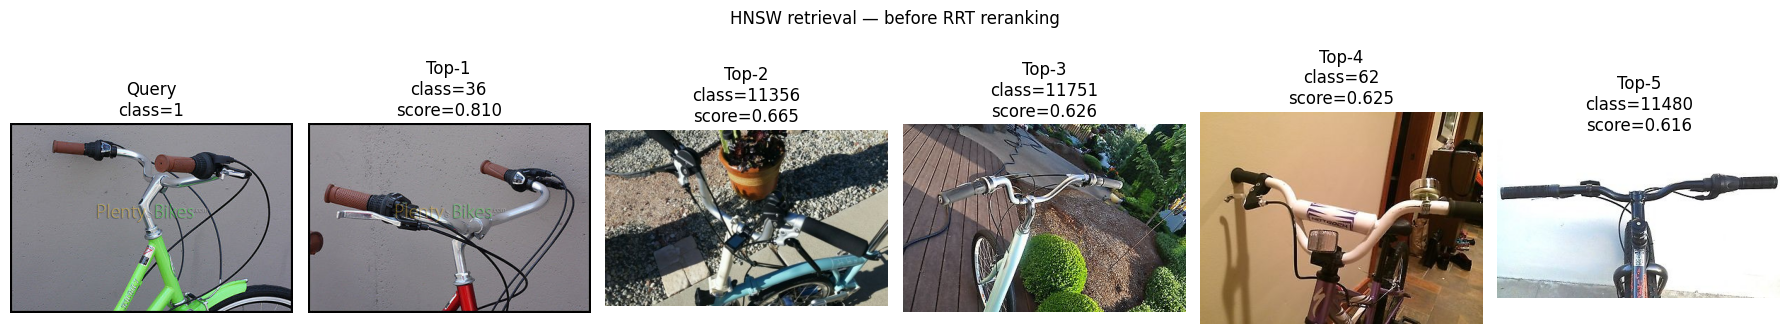

In [45]:
import matplotlib.pyplot as plt
from PIL import Image

n_show = 5

fig, axes = plt.subplots(1, n_show + 1, figsize=(18, 4))

# Query
axes[0].imshow(Image.open(query_path).convert("RGB"))
axes[0].set_title(
    f"Query\nclass={query_row['class_id']}"
)
axes[0].axis("off")

# Top-N trước RRT
for rank in range(n_show):
    row = candidate_df.iloc[rank]

    axes[rank + 1].imshow(
        Image.open(row["image_path"]).convert("RGB")
    )

    axes[rank + 1].set_title(
        f"Top-{rank+1}\n"
        f"class={row['class_id']}\n"
        f"score={q_scores[0, rank]:.3f}"
    )

    axes[rank + 1].axis("off")

plt.suptitle("HNSW retrieval — before RRT reranking")
plt.tight_layout()
plt.show()

## kiểm tra rằng từ Top-100 HNSW ta đã lấy được ảnh thật và biến chúng thành tensor để chuẩn bị đưa vào backbone ResNet50 của , During testing, each image is first resized to of 256 × 256 then cropped at the center to 224 × 224.

In [44]:
from PIL import Image
from torchvision import transforms

rrt_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

query_path = query_row["image_path"]

query_img = Image.open(query_path).convert("RGB")
query_tensor = rrt_transform(query_img).unsqueeze(0)

candidate_path = candidate_df.iloc[0]["image_path"]
candidate_img = Image.open(candidate_path).convert("RGB")
candidate_tensor = rrt_transform(candidate_img).unsqueeze(0)

print("Query tensor shape:", query_tensor.shape)
print("Candidate tensor shape:", candidate_tensor.shape)

Query tensor shape: torch.Size([1, 3, 224, 224])
Candidate tensor shape: torch.Size([1, 3, 224, 224])
